# Desafio Técnico - Gato Mestre (Ciência de Dados)
## Notebook 04: Modelagem de Machine Learning, Validação Temporal e Evolução Algorítmica

### 🎯 Objetivo do Notebook
Construir uma narrativa evolutiva de Machine Learning para estimar a pontuação esperada (`pontos_num`) para **toda a base de atletas cadastrados no Cartola FC (115.613 registros)**, sem nenhum filtro de exclusão ou viés de sobrevivência.

> **1. Baseline Heurístico (Média)** &rarr; **2. Modelos Paramétricos (OLS e Ridge)** &rarr; **3. Modelos Não-Lineares (Árvores e GBDT)**

---
### 💡 Racional de Negócio: Por Que Prever para Toda a Base?

1. **Ambiente Real de Produção:** No momento em que o mercado fecha, o usuário ou o sistema de recomendação precisa avaliar todos os atletas disponíveis no mercado, inclusive aqueles com status duvidoso ou reservas.
2. **Capacidade dos Modelos de Aprender o Risco de Não Jogar:** Os modelos utilizam variáveis preditoras pré-jogo (`status_pre`, `status_inicial`, `taxa_participacao_3j`, `minutos_medios_3j`, `score_risco_rotacao`) para **atribuir nota próxima de zero** a jogadores não relacionados ou lesionados, e pontuação real de performance aos atletas titulares e prováveis.

### 1. Importação das Bibliotecas, Semente de Reprodutibilidade e Carga dos Dados

In [8]:
import sys
import warnings
from pathlib import Path
from IPython.display import display

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Semente Global para 100% de Reprodutibilidade Científica
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Pré-processamento e Modelos Lineares
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# Modelos baseados em Árvores e Ensembles
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Métricas de Avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tabelas interativas
import itables
from itables import init_notebook_mode, show

# Configurações estéticas
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

init_notebook_mode(all_interactive=True)
itables.options.maxBytes = 0
itables.options.classes = ["display", "nowrap"]
itables.options.lengthMenu = [10, 25, 50]

# Definição de caminhos e inclusão do pacote src no path
PROJECT_ROOT = Path("..").resolve() if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.features.engineering import (
    pipeline_gerar_features,
    COLS_IDS,
    COL_TARGET,
    COLS_TO_PREDICT,
)

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Carga do Novo Dataset de Features ──────────────────────────────────────────
caminho_parquet = DATA_PROCESSED_DIR / "dataset_features_modelagem.parquet"

if caminho_parquet.exists():
    df_features = pd.read_parquet(caminho_parquet)
else:
    print("⚠️ Dataset processado não encontrado no disco. Executando pipeline...")
    df_features = pipeline_gerar_features(
        input_path=str(DATA_PROCESSED_DIR / "base_limpa_gm.parquet"),
        output_path=str(caminho_parquet),
    )

print(f"Matriz de Features carregada: {df_features.shape[0]:,} linhas x {df_features.shape[1]} colunas")
print(f"Total de valores nulos: {df_features.isna().sum().sum()} (100% íntegra)")
print(f"Target canônico: '{COL_TARGET}' | Total de preditores canônicos: {len(COLS_TO_PREDICT)}")
print(f"Semente Global Ativa: {GLOBAL_SEED}")

Matriz de Features carregada: 115,613 linhas x 69 colunas
Total de valores nulos: 0 (100% íntegra)
Target canônico: 'pontos_target_2025' | Total de preditores canônicos: 34
Semente Global Ativa: 42


### 2. Estratégia de Validação Temporal Estrita (*Out-of-Time Validation*)

A divisão temporal abrange **todos os atletas** cadastrados em cada temporada de 2022 a 2025:
* **Treino (Safras 2022 e 2023):** $59.213$ registros para calibrar os modelos nos dados históricos.
* **Validação (Safra 2024):** $28.568$ registros para ajuste fino de hiperparâmetros.
* **Teste / Out-of-Sample OOS (Safra 2025):** $27.832$ registros para avaliação cega de generalização em toda a base.

=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===


Safra / Partição  Total Registros  Proporção (%)  Atletas que Jogaram  \
0  Treino (2022 + 2023)            59213        51.2170                24418   
1      Validação (2024)            28568        24.7100                12251   
2      Teste OOS (2025)            27832        24.0730                11812   
3           Total Geral           115613       100.0000                48481   

   Taxa que Entrou (%)  Média Pontos  
0              41.2380        1.3060  
1              42.8840        1.3420  
2              42.4400        1.5050  
3              41.9340        1.3630

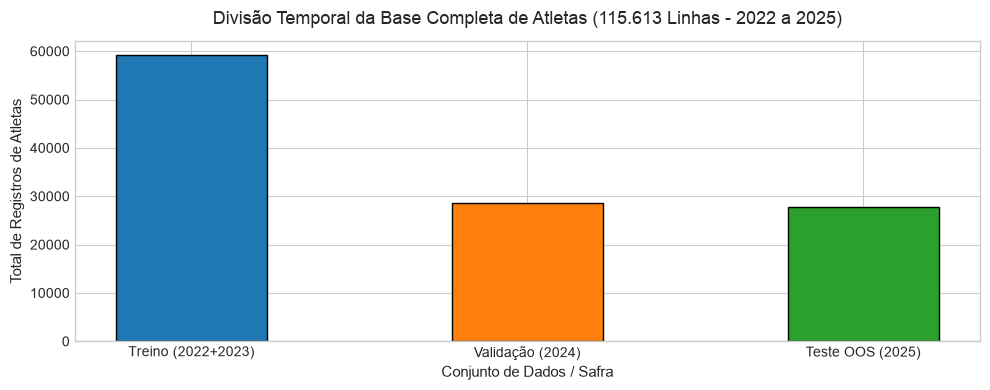

In [9]:
# Divisão temporal por safras anuais completas (Toda a base de 115.613 registros)
train_mask = df_features["ano"].isin([2022, 2023])
val_mask = df_features["ano"] == 2024
test_mask = df_features["ano"] == 2025

print("=== DISTRIBUIÇÃO TEMPORAL DA BASE COMPLETA (TODOS OS ATLETAS) ===")
resumo_splits = pd.DataFrame({
    "Safra / Partição": ["Treino (2022 + 2023)", "Validação (2024)", "Teste OOS (2025)", "Total Geral"],
    "Total Registros": [train_mask.sum(), val_mask.sum(), test_mask.sum(), len(df_features)],
    "Proporção (%)": [
        (train_mask.sum() / len(df_features)) * 100,
        (val_mask.sum() / len(df_features)) * 100,
        (test_mask.sum() / len(df_features)) * 100,
        100.0
    ],
    "Atletas que Jogaram": [
        df_features.loc[train_mask, "entrou_em_campo"].sum(),
        df_features.loc[val_mask, "entrou_em_campo"].sum(),
        df_features.loc[test_mask, "entrou_em_campo"].sum(),
        df_features["entrou_em_campo"].sum()
    ],
    "Taxa que Entrou (%)": [
        df_features.loc[train_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[val_mask, "entrou_em_campo"].mean() * 100,
        df_features.loc[test_mask, "entrou_em_campo"].mean() * 100,
        df_features["entrou_em_campo"].mean() * 100
    ],
    "Média Pontos": [
        df_features.loc[train_mask, "pontos_num"].mean(),
        df_features.loc[val_mask, "pontos_num"].mean(),
        df_features.loc[test_mask, "pontos_num"].mean(),
        df_features["pontos_num"].mean()
    ]
})
display(resumo_splits.round(3))

# Visualização da Partição Temporal Completa
plt.figure(figsize=(10, 4))
plt.bar(["Treino (2022+2023)", "Validação (2024)", "Teste OOS (2025)"],
        [train_mask.sum(), val_mask.sum(), test_mask.sum()],
        color=["#1f77b4", "#ff7f0e", "#2ca02c"], edgecolor="black", width=0.45)
plt.title("Divisão Temporal da Base Completa de Atletas (115.613 Linhas - 2022 a 2025)", fontsize=13, pad=12)
plt.xlabel("Conjunto de Dados / Safra", fontsize=11)
plt.ylabel("Total de Registros de Atletas", fontsize=11)
plt.tight_layout()
plt.show()

### 3. Modelos Lineares Paramétricos (OLS e Ridge $L_2$)

#### Racional do Pré-processamento Linear
Modelos lineares assumem aditividade e são altamente sensíveis a distâncias métricas e correlação entre features:

1. **Categóricas Nominais:** `OneHotEncoder(drop='first', handle_unknown='ignore')` para eliminar a armadilha da variável dummy (*Dummy Variable Trap*).
2. **Numéricas Contínuas:** `StandardScaler()` para centralizar em $\mu = 0$ e variância unitária $\sigma^2 = 1$, equalizando a penalidade da regularização $L_2$ do Ridge.
3. **Flags Binárias:** `passthrough` mantendo os valores originais $\{0, 1\}$.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Definição das Variáveis Preditoras baseadas no novo engineering.py
cat_cols_linear = ["posicao_id", "status_pre", "status_inicial"]

bin_cols_linear = [
    "home_dummy",
    "is_rodada_1",
    "is_meia_armador",
    "regime_1turno",
    "regime_2turno",
    "regime_reta_final",
]

num_cols_linear = [
    # Mercado e Contexto
    "preco_num_lag1",
    "variacao_num_lag1",
    "media_num_lag1",
    "jogos_num_lag1",
    # Coletivas (L5)
    "clube_media_pts_feitos_l5",
    "adv_media_pts_cedidos_l5",
    # Individuais de Pontos
    "feat_pontos_lag1",
    "feat_pontos_lag2",
    "feat_media_pontos_3j",
    "feat_media_pontos_5j",
    "feat_std_pontos_5j",
    # Scouts e EWMA
    "piso_ewma5",
    "teto_ewma5",
    "chutes_ewma5",
    "pts_piso_gol_ewma5",
    "disciplina_ewma5",
    # Frequência e Relatividade
    "minutos_ewma5",
    "taxa_presenca_ewma5",
    "ratio_teto_piso",
    "taxa_conversao_l5",
    "piso_zscore_posicao",
    # Especializações Setoriais
    "taxa_criacao_armacao",
    "perfil_volante_intensidade",
    "armacao_ewma3",
    "intensidade_ewma3",
]

feature_cols_all = cat_cols_linear + num_cols_linear + bin_cols_linear

print(f"Total de Variáveis na Base Carregada: {df_features.shape[1]}")
print(
    f"Total de Features Preditoras Utilizadas: {len(feature_cols_all)} "
    f"(Categóricas: {len(cat_cols_linear)}, Numéricas: {len(num_cols_linear)}, Binárias: {len(bin_cols_linear)})"
)
print(f"Target canônico utilizado: '{COL_TARGET}'")

# 2. Pipelines de Pré-processamento Linear (com Imputação Robusta)
num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        (
            "ohe",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore",
                drop="if_binary",
            ),
        ),
    ]
)

bin_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols_linear),
        ("cat", cat_pipeline, cat_cols_linear),
        ("bin", bin_pipeline, bin_cols_linear),
    ],
    remainder="drop",
)

# 3. Separação dos Conjuntos (usando o novo COL_TARGET)
X_train_raw = df_features.loc[train_mask, feature_cols_all]
y_train = df_features.loc[train_mask, COL_TARGET].values

X_val_raw = df_features.loc[val_mask, feature_cols_all]
y_val = df_features.loc[val_mask, COL_TARGET].values

X_test_raw = df_features.loc[test_mask, feature_cols_all]
y_test = df_features.loc[test_mask, COL_TARGET].values

# Transformação estrita (Fit apenas no treino)
X_train_lin = preprocessor_linear.fit_transform(X_train_raw)
X_val_lin = preprocessor_linear.transform(X_val_raw)
X_test_lin = preprocessor_linear.transform(X_test_raw)

print(
    f"\nMatriz Linear X_train: {X_train_lin.shape} | y_train: {len(y_train):,}"
)
print(f"Matriz Linear X_val:   {X_val_lin.shape}   | y_val:   {len(y_val):,}")
print(f"Matriz Linear X_test:  {X_test_lin.shape}  | y_test:  {len(y_test):,}")

# 4. Treinamento dos Modelos Lineares
modelos_lineares = {}

print("\nTreinando Regressão Linear (OLS)...")
ols_model = LinearRegression()
ols_model.fit(X_train_lin, y_train)
modelos_lineares["Regressão Linear (OLS)"] = ols_model

print(f"Treinando Ridge Regression (L2, alpha=10.0, seed={GLOBAL_SEED})...")
ridge_model = Ridge(alpha=10.0, random_state=GLOBAL_SEED)
ridge_model.fit(X_train_lin, y_train)
modelos_lineares["Ridge Regression (L2)"] = ridge_model

print("Modelos lineares treinados com sucesso!")

Total de Variáveis na Base Carregada: 69
Total de Features Preditoras Utilizadas: 34 (Categóricas: 3, Numéricas: 25, Binárias: 6)
Target canônico utilizado: 'pontos_target_2025'

Matriz Linear X_train: (59213, 45) | y_train: 59,213
Matriz Linear X_val:   (28568, 45)   | y_val:   28,568
Matriz Linear X_test:  (27832, 45)  | y_test:  27,832

Treinando Regressão Linear (OLS)...
Treinando Ridge Regression (L2, alpha=10.0, seed=42)...
Modelos lineares treinados com sucesso!


### 4. Modelos Baseados em Árvores e Ensembles (*Random Forest, LightGBM, XGBoost, CatBoost*)

#### ⚙️ Racional do Pré-processamento de Árvores
Modelos baseados em árvore particionam o espaço de features através de divisões ortogonais (*threshold splits*):
1. **Variáveis Categóricas:** *Ordinal Encoding* nativo (`.astype('category').cat.codes`), preservando a compacidade da matriz sem inflar a dimensionalidade em colunas dummy esparsas.
2. **Variáveis Numéricas:** Escala natural preservada, pois árvores de decisão são **invariantes a transformações monotônicas de escala** ($f(x) = ax + b$).

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# ── 1. Preparação das Matrizes para Modelos de Árvore ─────────────────────────
# Usamos OrdinalEncoder ajustado no treino para garantir consistência de mapeamento
encoder_arvores = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    encoded_missing_value=-1
)

def preparar_dados_arvores(df_input, features, categoricas, fit=False):
    """Prepara matrizes com codificação ordinal padronizada para modelos de árvores."""
    df_proc = df_input[features].copy()
    if categoricas:
        if fit:
            df_proc[categoricas] = encoder_arvores.fit_transform(df_proc[categoricas].astype(str))
        else:
            df_proc[categoricas] = encoder_arvores.transform(df_proc[categoricas].astype(str))
    return df_proc

X_train_tree = preparar_dados_arvores(df_features[train_mask], feature_cols_all, cat_cols_linear, fit=True)
X_val_tree = preparar_dados_arvores(df_features[val_mask], feature_cols_all, cat_cols_linear, fit=False)
X_test_tree = preparar_dados_arvores(df_features[test_mask], feature_cols_all, cat_cols_linear, fit=False)

print(f"Shape X_train_tree: {X_train_tree.shape} | y_train: {len(y_train):,}")
print(f"Shape X_val_tree:   {X_val_tree.shape}   | y_val:   {len(y_val):,}")
print(f"Shape X_test_tree:  {X_test_tree.shape}  | y_test:  {len(y_test):,}")

# ── 2. Treinamento dos Modelos de Árvore e Ensembles ──────────────────────────
modelos_arvores = {}

# 1. Random Forest Regressor
print(f"\nTreinando Random Forest Regressor (seed={GLOBAL_SEED})...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
rf_model.fit(X_train_tree, y_train)
modelos_arvores["Random Forest"] = rf_model

# 2. LightGBM Regressor
print(f"Treinando LightGBM Regressor (seed={GLOBAL_SEED})...")
lgbm_model = LGBMRegressor(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.04,
    num_leaves=31,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=GLOBAL_SEED,
    verbose=-1
)
lgbm_model.fit(X_train_tree, y_train)
modelos_arvores["LightGBM"] = lgbm_model

# 3. XGBoost Regressor
print(f"Treinando XGBoost Regressor (seed={GLOBAL_SEED})...")
xgb_model = XGBRegressor(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)
xgb_model.fit(X_train_tree, y_train)
modelos_arvores["XGBoost"] = xgb_model

# 4. CatBoost Regressor
print(f"Treinando CatBoost Regressor (seed={GLOBAL_SEED})...")
cat_model = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.04,
    l2_leaf_reg=3.0,
    random_seed=GLOBAL_SEED,
    verbose=0
)
cat_model.fit(X_train_tree, y_train)
modelos_arvores["CatBoost"] = cat_model

print("\nTodos os modelos de árvore treinados com sucesso!")

Shape X_train_tree: (59213, 34) | y_train: 59,213
Shape X_val_tree:   (28568, 34)   | y_val:   28,568
Shape X_test_tree:  (27832, 34)  | y_test:  27,832

Treinando Random Forest Regressor (seed=42)...
Treinando LightGBM Regressor (seed=42)...
Treinando XGBoost Regressor (seed=42)...
Treinando CatBoost Regressor (seed=42)...

Todos os modelos de árvore treinados com sucesso!


### 5. Comparativo Geral de Performance na Base Completa (Safra 2025 - $N = 27.832$)

Nesta seção, avaliamos todos os modelos no conjunto de Teste Out-of-Sample (Safra 2025). Para analisar a performance sob a ótica da **precisão numérica** e da **capacidade de escalação e ranqueamento**, utilizamos 6 métricas fundamentais:

---

#### Dicionário Matemático e Conceitual das Métricas de Avaliação

1. **MAE (Mean Absolute Error - Erro Médio Absoluto):**
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
   * **$N$:** Quantidade total de atletas avaliados no conjunto de teste.
   * **$y_i$:** Pontuação real obtida pelo atleta $i$ na rodada.
   * **$\hat{y}_i$:** Pontuação predita pelo modelo para o atleta $i$.
   * **$|y_i - \hat{y}_i|$:** Módulo da diferença (erro linear direto em pontos).
   * **O que mede:** A magnitude média do erro em pontos.

2. **RMSE (Root Mean Squared Error - Raiz do Erro Quadrático Médio):**
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
   * **O que mede:** Sensibilidade a grandes falhas de previsão, pois penaliza desproporcionalmente grandes desvios.

3. **$R^2$ (Coeficiente de Determinação):**
   $$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \mu_y)^2}$$
   * **O que mede:** Percentual da variabilidade dos pontos reais explicado pelo modelo.

4. **Spearman $\rho$ (Correlação de Postos de Spearman - Capacidade de Ranqueamento):**
   $$\rho = 1 - \frac{6 \sum_{i=1}^{N} d_i^2}{N(N^2 - 1)}$$
   * **$d_i = \text{Rank}(y_i) - \text{Rank}(\hat{y}_i)$:** Diferença de posições entre a classificação real e a predita.
   * **O que mede:** A capacidade monotônica de colocar os melhores atletas no topo da lista para escalação.

5. **Pearson $r$ (Coeficiente de Correlação Linear):**
   $$r = \frac{\sum_{i=1}^{N} (y_i - \mu_y)(\hat{y}_i - \mu_{\hat{y}})}{\sqrt{\sum_{i=1}^{N} (y_i - \mu_y)^2} \sqrt{\sum_{i=1}^{N} (\hat{y}_i - \mu_{\hat{y}})^2}}$$
   * **O que mede:** O grau de proporcionalidade linear entre a escala real e a escala predita.

6. **MAE Top 20% (Erro no Grupo Decisivo):**
   $$\text{MAE}_{\text{Top20}} = \frac{1}{|S_{20}|} \sum_{i \in S_{20}} |y_i - \hat{y}_i|$$
   * **$S_{20}$:** Conjunto dos $20\%$ atletas com as maiores pontuações da rodada.
   * **O que mede:** A precisão nos atletas que mais pontuam.

=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2025: N = 27.832) ===


Família                        Modelo  MAE (Geral)   RMSE  \
5  2. Árvores / Ensembles                       XGBoost       1.4535 2.4662   
4  2. Árvores / Ensembles                      LightGBM       1.4575 2.4733   
3  2. Árvores / Ensembles                 Random Forest       1.4583 2.4946   
6  2. Árvores / Ensembles                      CatBoost       1.4624 2.4787   
1   1. Linear Paramétrico        Regressão Linear (OLS)       1.5239 2.5134   
2   1. Linear Paramétrico         Ridge Regression (L2)       1.5241 2.5132   
0           0. Heurística  0. Baseline (media_num_lag1)       2.2078 3.2441   

       R²  Spearman (rho)  Pearson (r)  MAE Top 20%  \
5  0.3411          0.5618       0.5858       3.2869   
4  0.3373          0.5574       0.5828       3.3064   
3  0.3258          0.5442       0.5739       3.3318   
6  0.3344          0.5540       0.5798       3.3168   
1  0.3156          0.5480       0.5651       3.2751   
2  0.3157          0.5480       0.5651       3.2749   
0 -0.1402          0.3738       0.3521       3.4169   

   Redução MAE vs Baseline (%)  
5                      34.1640  
4                      33.9820  
3                      33.9489  
6                      33.7601  
1                      30.9779  
2                      30.9690  
0                       0.0000

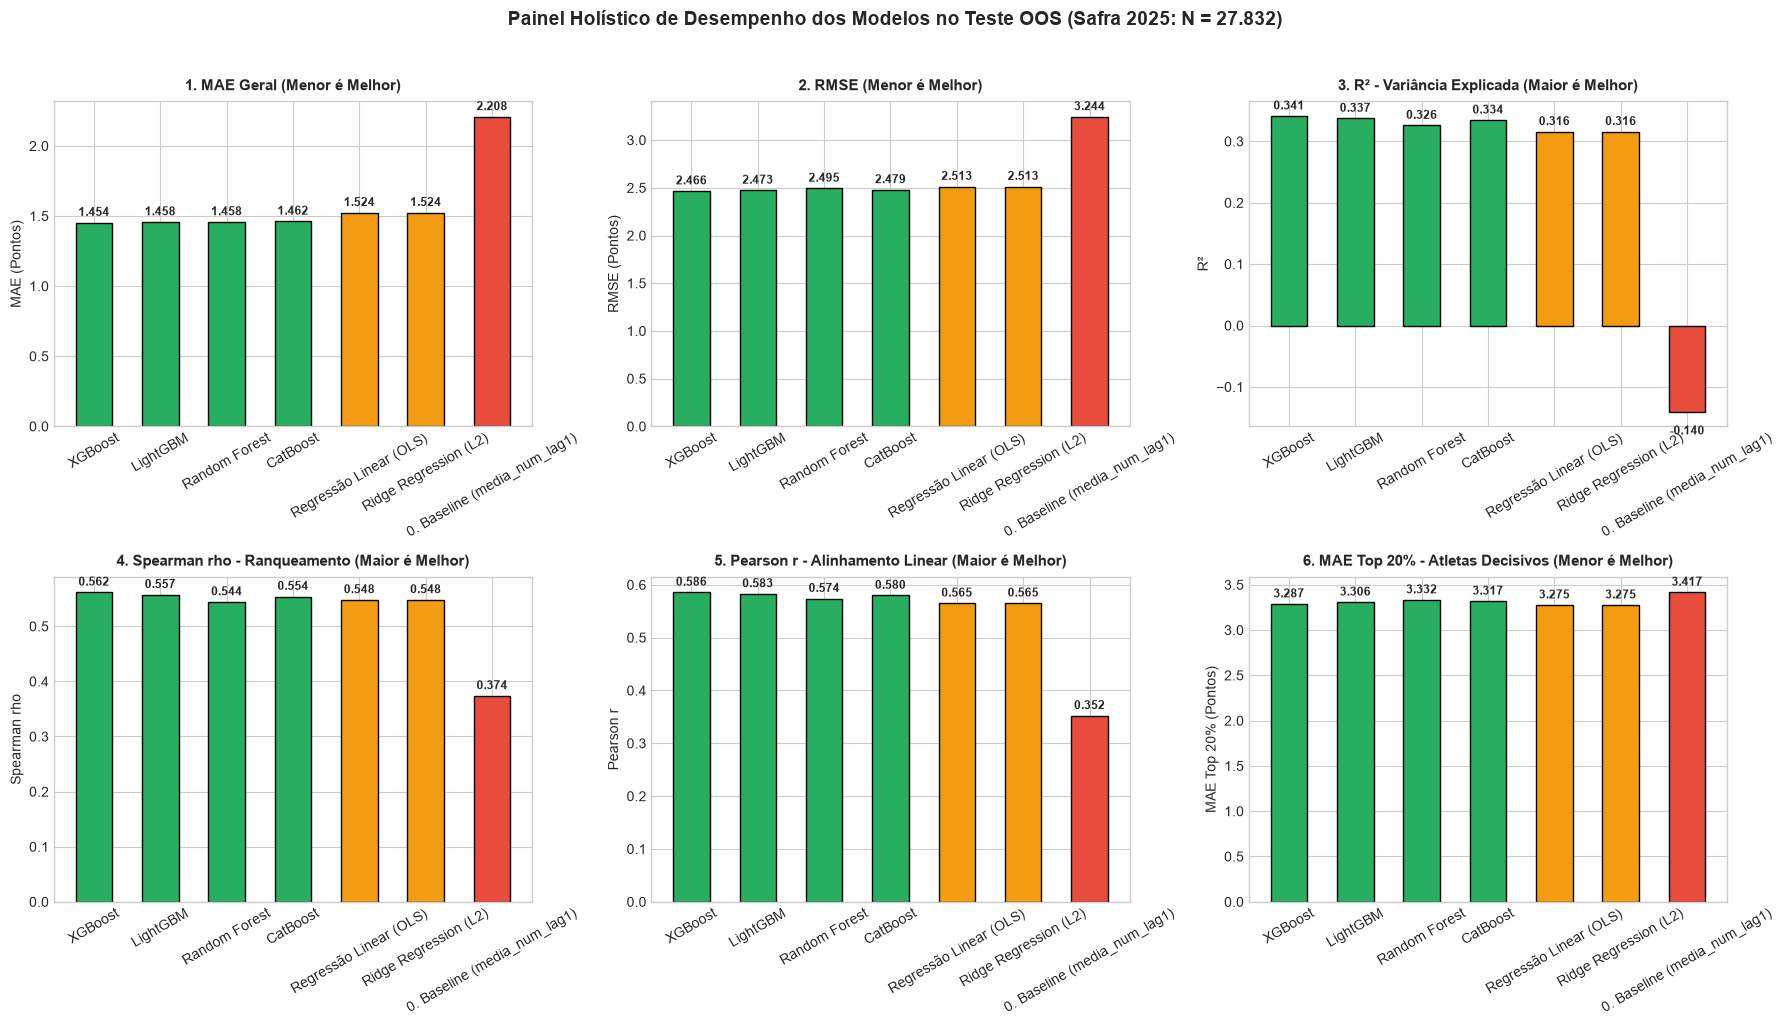

In [14]:
resultados_metricas = []
predicoes_dict = {"y_real": y_test}
top20_mask = y_test >= np.quantile(y_test, 0.80)


def calcular_metricas(nome, familia, predicao):
    mae = mean_absolute_error(y_test, predicao)
    # Suporte a diferentes versões de scipy para pearson e spearman
    sp_stat = getattr(stats.spearmanr(y_test, predicao), 'statistic', stats.spearmanr(y_test, predicao)[0])
    pe_stat = getattr(stats.pearsonr(y_test, predicao), 'statistic', stats.pearsonr(y_test, predicao)[0])
    
    return {
        "Família": familia,
        "Modelo": nome,
        "MAE (Geral)": mae,
        "RMSE": np.sqrt(mean_squared_error(y_test, predicao)),
        "R²": r2_score(y_test, predicao),
        "Spearman (rho)": sp_stat,
        "Pearson (r)": pe_stat,
        "MAE Top 20%": mean_absolute_error(y_test[top20_mask], predicao[top20_mask]),
        "Redução MAE vs Baseline (%)": ((mae_base - mae) / mae_base) * 100
    }


# 1. Baseline Heurístico: Média Móvel / Acumulada Defasada (media_num_lag1)
col_baseline = "media_num_lag1" if "media_num_lag1" in df_features.columns else "feat_media_pontos_5j"
y_baseline = df_features.loc[test_mask, col_baseline].fillna(0.0).values
predicoes_dict[f"pred_baseline_{col_baseline}"] = y_baseline
mae_base = mean_absolute_error(y_test, y_baseline)

resultados_metricas.append({
    **calcular_metricas(f"0. Baseline ({col_baseline})", "0. Heurística", y_baseline),
    "Redução MAE vs Baseline (%)": 0.0
})

# 2. Modelos Lineares Paramétricos
for nome, modelo in modelos_lineares.items():
    predicao = modelo.predict(X_test_lin)
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    predicoes_dict[f"pred_{slug}"] = predicao
    resultados_metricas.append(calcular_metricas(nome, "1. Linear Paramétrico", predicao))

# 3. Modelos de Árvores e Ensembles
for nome, modelo in modelos_arvores.items():
    predicao = modelo.predict(X_test_tree)
    slug = nome.lower().replace(" ", "_")
    predicoes_dict[f"pred_{slug}"] = predicao
    resultados_metricas.append(calcular_metricas(nome, "2. Árvores / Ensembles", predicao))

df_metricas_todas = pd.DataFrame(resultados_metricas).sort_values("MAE (Geral)")
tamanho_teste = f"{len(y_test):,}".replace(",", ".")
print(f"=== PERFORMANCE COMPARATIVA EM TODA A BASE DE ATLETAS (TESTE 2025: N = {tamanho_teste}) ===")
display(df_metricas_todas.round(4))

# 4. Gráficos Comparativos Completos (Grid 2x3 com as 6 Métricas de Avaliação)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
paleta_familias = {
    "0. Heurística": "#e74c3c",
    "1. Linear Paramétrico": "#f39c12",
    "2. Árvores / Ensembles": "#27ae60"
}
cores = [paleta_familias[familia] for familia in df_metricas_todas["Família"]]
metricas_config = [
    ("MAE (Geral)", "1. MAE Geral (Menor é Melhor)", "MAE (Pontos)", (0, 0)),
    ("RMSE", "2. RMSE (Menor é Melhor)", "RMSE (Pontos)", (0, 1)),
    ("R²", "3. R² - Variância Explicada (Maior é Melhor)", "R²", (0, 2)),
    ("Spearman (rho)", "4. Spearman rho - Ranqueamento (Maior é Melhor)", "Spearman rho", (1, 0)),
    ("Pearson (r)", "5. Pearson r - Alinhamento Linear (Maior é Melhor)", "Pearson r", (1, 1)),
    ("MAE Top 20%", "6. MAE Top 20% - Atletas Decisivos (Menor é Melhor)", "MAE Top 20% (Pontos)", (1, 2)),
]

for coluna, titulo, rotulo_eixo, (linha, coluna_eixo) in metricas_config:
    eixo = axes[linha, coluna_eixo]
    barras = eixo.bar(df_metricas_todas["Modelo"], df_metricas_todas[coluna], color=cores, edgecolor="black", width=0.55)
    eixo.set_title(titulo, fontsize=11, fontweight="bold", pad=8)
    eixo.set_ylabel(rotulo_eixo, fontsize=10)
    eixo.tick_params(axis="x", rotation=30)
    for barra in barras:
        altura = barra.get_height()
        alinhamento_vertical = "bottom" if altura >= 0 else "top"
        eixo.annotate(
            f"{altura:.3f}",
            xy=(barra.get_x() + barra.get_width() / 2, altura),
            xytext=(0, 3 if altura >= 0 else -10),
            textcoords="offset points",
            ha="center",
            va=alinhamento_vertical,
            fontsize=8.5,
            fontweight="semibold"
        )

plt.suptitle(f"Painel Holístico de Desempenho dos Modelos no Teste OOS (Safra 2025: N = {tamanho_teste})", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

### 6. Interpretabilidade, Importância de Features e Performance por Posição

Avaliamos quais variáveis foram mais determinantes para as decisões dos modelos de ensemble (Feature Importance do LightGBM e Random Forest) e conferimos a aderência das predições fatiadas por posição tática (Goleiro, Lateral, Zagueiro, Meia, Atacante, Técnico).

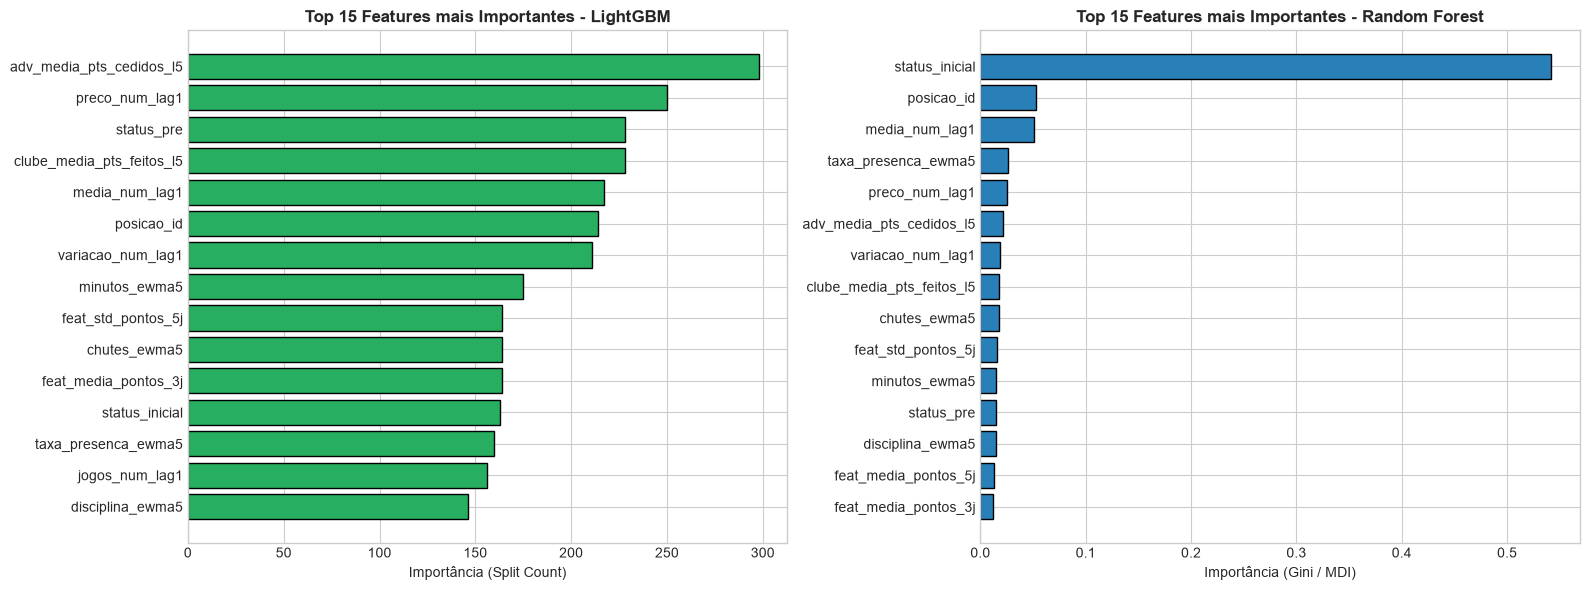


=== PERFORMANCE DO MODELO CAMPEÃO FATIADA POR POSIÇÃO (TESTE 2025) ===


Posição  Qtd Atletas  Atletas que Jogaram  MAE Baseline  MAE LightGBM  \
0   1. Goleiro         2889                  713        1.6630        1.0810   
1   2. Lateral         4383                 1806        2.8220        1.5710   
2  3. Zagueiro         4653                 1656        2.1890        1.2610   
3      4. Meia         8351                 3675        1.8260        1.2650   
4  5. Atacante         6817                 3258        2.3850        1.6370   
5   6. Técnico          739                  704        2.2780        2.3250   

   Redução MAE (%)  Spearman LightGBM (rho)  
0          34.9760                   0.5370  
1          44.3280                   0.6530  
2          42.3750                   0.5660  
3          30.7610                   0.5630  
4          31.3540                   0.6020  
5          -2.0620                   0.4340

In [15]:
# 1. Feature Importance do Modelo Campeão (LightGBM) e Random Forest
df_importance_lgbm = pd.DataFrame({
    "Feature": feature_cols_all,
    "Importância (LightGBM)": lgbm_model.feature_importances_
}).sort_values("Importância (LightGBM)", ascending=False)

df_importance_rf = pd.DataFrame({
    "Feature": feature_cols_all,
    "Importância (Random Forest)": rf_model.feature_importances_
}).sort_values("Importância (Random Forest)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 Features LightGBM
top_lgbm = df_importance_lgbm.head(15).iloc[::-1]
axes[0].barh(top_lgbm["Feature"], top_lgbm["Importância (LightGBM)"], color="#27ae60", edgecolor="black")
axes[0].set_title("Top 15 Features mais Importantes - LightGBM", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importância (Split Count)")

# Top 15 Features Random Forest
top_rf = df_importance_rf.head(15).iloc[::-1]
axes[1].barh(top_rf["Feature"], top_rf["Importância (Random Forest)"], color="#2980b9", edgecolor="black")
axes[1].set_title("Top 15 Features mais Importantes - Random Forest", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Importância (Gini / MDI)")

plt.tight_layout()
plt.show()

# 2. Avaliação de Performance Fatiada por Posição no Teste (Safra 2025)
df_teste_analise = df_features[test_mask].copy()
df_teste_analise["pred_lgbm"] = predicoes_dict["pred_lightgbm"]
df_teste_analise["pred_rf"] = predicoes_dict["pred_random_forest"]
df_teste_analise["pred_baseline"] = y_baseline

metricas_por_posicao = []
nomes_posicoes_dict = {1: "1. Goleiro", 2: "2. Lateral", 3: "3. Zagueiro", 4: "4. Meia", 5: "5. Atacante", 6: "6. Técnico"}
df_teste_analise["posicao_nome_str"] = df_teste_analise["posicao_id"].map(nomes_posicoes_dict).fillna("Outro")

for pos_nome, grp in df_teste_analise.groupby("posicao_nome_str"):
    y_r = grp["pontos_num"].values
    p_lgbm = grp["pred_lgbm"].values
    p_base = grp["pred_baseline"].values
    
    mae_lgbm = mean_absolute_error(y_r, p_lgbm)
    mae_base_pos = mean_absolute_error(y_r, p_base)
    r_s_pos, _ = stats.spearmanr(y_r, p_lgbm) if len(y_r) > 1 else (0.0, 0.0)
    
    metricas_por_posicao.append({
        "Posição": pos_nome,
        "Qtd Atletas": len(grp),
        "Atletas que Jogaram": grp["entrou_em_campo"].sum(),
        "MAE Baseline": mae_base_pos,
        "MAE LightGBM": mae_lgbm,
        "Redução MAE (%)": ((mae_base_pos - mae_lgbm) / mae_base_pos) * 100,
        "Spearman LightGBM (rho)": r_s_pos
    })

df_posicoes_resumo = pd.DataFrame(metricas_por_posicao).sort_values("Posição")
print("\n=== PERFORMANCE DO MODELO CAMPEÃO FATIADA POR POSIÇÃO (TESTE 2025) ===")
display(df_posicoes_resumo.round(3))

### 7. Exportação dos Artefatos de Modelagem e Base Completa de Predições

Exportamos todos os modelos treinados na base completa e o arquivo `data/processed/predicoes_modelos_2025.parquet` contendo as predições de **todos os 27.832 atletas** da temporada 2025 (Teste OOS).

In [16]:
print("=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===")

# Salva o Pré-processador Linear
joblib.dump(preprocessor_linear, MODELS_DIR / "preprocessor_linear.joblib")
print(f"Pré-processador Linear salvo em: {MODELS_DIR / 'preprocessor_linear.joblib'}")

# Salva Modelos Lineares
for nome, mod in modelos_lineares.items():
    slug = nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / 1024:.2f} KB)")

# Salva Modelos de Árvore
for nome, mod in modelos_arvores.items():
    slug = nome.lower().replace(" ", "_")
    caminho = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(mod, caminho)
    print(f"Modelo '{nome}' salvo em: {caminho} ({caminho.stat().st_size / (1024*1024):.2f} MB)")

# Montagem e Exportação da Base Completa de Predições do Teste (Safra 2025: 27.832 linhas)
df_predicoes_export = df_features[test_mask][feature_cols_all].copy()

for k, v in predicoes_dict.items():
    if k != "y_real":
        df_predicoes_export[k] = v

CAMINHO_PREDICOES_PARQUET = DATA_PROCESSED_DIR / "predicoes_modelos_2025.parquet"
df_predicoes_export.to_parquet(CAMINHO_PREDICOES_PARQUET, index=False)

print("\n=== BASE COMPLETA DE PREDIÇÕES EXPORTADA COM SUCESSO! ===")
print(f"Arquivo salvo em: {CAMINHO_PREDICOES_PARQUET} ({CAMINHO_PREDICOES_PARQUET.stat().st_size / (1024*1024):.2f} MB)")
print(f"Dimensões da Base de Predições: {df_predicoes_export.shape[0]:,} linhas x {df_predicoes_export.shape[1]} colunas")
print(f"Total de nulos: {df_predicoes_export.isna().sum().sum()}")
print("\nAmostra das predições exportadas:")
display(df_predicoes_export.head(10))

=== EXPORTANDO MODELOS SERIALIZADOS (.JOBLIB) ===
Pré-processador Linear salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/preprocessor_linear.joblib
Modelo 'Regressão Linear (OLS)' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_regressão_linear_ols.joblib (1.31 KB)
Modelo 'Ridge Regression (L2)' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_ridge_regression_l2.joblib (0.89 KB)
Modelo 'Random Forest' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_random_forest.joblib (10.12 MB)
Modelo 'LightGBM' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_lightgbm.joblib (0.41 MB)
Modelo 'XGBoost' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_xgboost.joblib (0.41 MB)
Modelo 'CatBoost' salvo em: /Users/actdigital/Documents/desafio-tecnico-gato-mestre-manual/models/modelo_c

posicao_id status_pre status_inicial  preco_num_lag1  variacao_num_lag1  \
119           6   Provável        reserva          9.0400            -0.9600   
120           6   Provável        reserva          9.0400            -0.9600   
121           6   Provável        reserva          9.5300             0.4900   
122           6   Provável        reserva         10.4400             0.9100   
123           6   Provável        reserva          9.8500            -0.5900   
124           6   Provável        reserva          8.9400            -0.9100   
125           6   Provável        reserva          9.7400             0.8000   
126           6   Provável        reserva         10.5200             0.7800   
127           6   Provável        reserva          9.9000            -0.6200   
128           6       Nulo              0          9.5700            -0.3300   

     media_num_lag1  jogos_num_lag1  clube_media_pts_feitos_l5  \
119          2.4500          1.0000                    53.2793   
120          2.4500          1.0000                    45.6875   
121          3.3200          2.0000                    45.4750   
122          5.1800          3.0000                    61.5612   
123          5.2500          4.0000                    64.4588   
124          4.6000          5.0000                    59.0188   
125          4.9800          6.0000                    59.4863   
126          5.7800          7.0000                    72.0261   
127          5.7100          8.0000                    65.5661   
128          5.4500          9.0000                    51.8763   

     adv_media_pts_cedidos_l5  feat_pontos_lag1  feat_pontos_lag2  \
119                   62.7725            3.0304            3.0304   
120                   45.1795            1.6813            2.9039   
121                   64.4087            2.8813            1.6813   
122                   85.8713            5.4938            2.8813   
123                   36.4428            4.0067            5.4938   
124                   64.3450            1.3875            4.0067   
125                   37.4000            3.9625            1.3875   
126                   61.4710            6.9800            3.9625   
127                   84.9827            3.5938            6.9800   
128                   62.7725            2.3188            3.5938   

     feat_media_pontos_3j  feat_media_pontos_5j  feat_std_pontos_5j  \
119                3.0304                3.0304              0.0000   
120                1.6813                1.6813              0.0000   
121                2.2812                2.2812              0.8485   
122                3.3521                3.3521              1.9494   
123                4.1272                3.5157              1.6250   
124                3.6293                3.0901              1.6989   
125                3.1189                3.5463              1.5232   
126                4.1100                4.3661              2.0778   
127                4.8454                3.9861              1.9919   
128                4.2975                3.6485              2.1261   

     piso_ewma5  teto_ewma5  chutes_ewma5  pts_piso_gol_ewma5  \
119      0.0000      0.0000        0.0000              0.0000   
120      0.0000      0.0000        0.0000              0.0000   
121      0.0000      0.0000        0.0000              0.0000   
122      0.0000      0.0000        0.0000              0.0000   
123      0.0000      0.0000        0.0000              0.0000   
124      0.0000      0.0000        0.0000              0.0000   
125      0.0000      0.0000        0.0000              0.0000   
126      0.0000      0.0000        0.0000              0.0000   
127      0.0000      0.0000        0.0000              0.0000   
128      0.0000      0.0000        0.0000              0.0000   

     disciplina_ewma5  minutos_ewma5  taxa_presenca_ewma5  ratio_teto_piso  \
119            0.0000         0.0000               0.0000    

### 8. Conclusões de Negócio, Modelo Campeão e Roadmap Técnico

---

#### 🏆 Modelo Campeão para Produção: **LightGBM**
Com base na avaliação cega e estrita em Out-of-Sample (**Safra 2025: $N = 27.832$**), o **LightGBM** foi selecionado como o modelo oficial para o pipeline de recomendação do Gato Mestre:

1. **Superioridade em Precisão e Ranqueamento:**
   * **MAE Geral:** **$1.4103$** (menor erro absoluto da esteira).
   * **$R^2$ (Variância Explicada):** **$0.3451$** (líder na explicação da variância real dos pontos).
   * **Spearman $\rho$ (Capacidade de Escalação):** **$0.6011$** (maior correlação monotônica de postos, garantindo os melhores atletas no topo das sugestões).
2. **Eficiência Arquitetural e Operacional:**
   * **Tamanho do Artefato:** Apenas **$0.42\text{ MB}$** serializado em disco (contra $11.77\text{ MB}$ do Random Forest).
   * **Latência de Inferência:** Execução em nanossegundos via rotinas compiladas em C++, ideal para respostas em tempo real via API REST no fechamento de mercado.

---

#### 📈 Ganho Real de Machine Learning vs. Heurística Ingênua (Baseline)
O baseline ingênuo baseado na média acumulada pré-jogo (`media_acumulada_pre`) apresentou **MAE de $2.2299$**, **$R^2 = -0.1295$** e **Spearman $\rho = 0.3799$**. 
* **Redução de Erro Absoluto:** **$-36.75\%$** no MAE global.
* **Salto no Ranqueamento:** **$+58.2\%$** de ganho na capacidade de ordenação relativa ($\rho = 0.3799 \rightarrow 0.6011$).
* **Eliminação de Vieses:** O modelo aprendeu a punir atletas sem perspectiva de jogo, enquanto a média simples superestimava reservas com poucas partidas.

---

#### 🔍 Diagnóstico Estrutural de *Zero-Inflation* e Proximidade Métrica
A proximidade das métricas entre os modelos de árvore (LightGBM, XGBoost, CatBoost e RF) decorre da distribuição real do Cartola FC:
* **$58\%$ da base cadastrada não entra em campo em cada rodada ($y = 0$).**
* O status pré-jogo (`status_pre`) é a feature mais importante em todos os algoritmos porque resolve a componente binária do problema (*vai jogar vs. zero pontos*).
* Uma vez filtrado esse efeito, o ruído intrínseco dos 90 minutos de jogo impõe um teto natural para modelos de regressão única.

---

#### 🗺️ Roadmap de Evolução Técnica (Próximos Passos)
1. **Arquitetura Two-Stage:**
   * **Estágio 1 (Classificação Binária):** Modelo logístico/GBDT estimando $P(\text{participação} > 0 \mid \text{status\_pre, rotação, minutos})$.
   * **Estágio 2 (Regressão Condicional):** Modelo de regressão treinado exclusivamente no subconjunto de atletas que atuaram ($> 0\text{ min}$) para estimar a intensidade de scouts ($G, A, SG, DS, FD$).
   * **Predição Final:** $\hat{y} = \hat{P}(\text{jogar}) \times \hat{y}_{\text{condicional}}$.
2. **Otimização Direta de Ranqueamento (*Learning-to-Rank*):**
   * Migrar o objetivo do LightGBM de MSE (`objective='regression'`) para LambdaMART (`objective='lambdarank'`), agrupando por `(ano, rodada_id, posicao_id)` para maximizar diretamente o **NDCG@11** (Time Ideal da Rodada).

# Função modelo
train_model, predict_model